In [1]:
#import libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Repairs and Assets data EDA

In [2]:
#Loading dataset

repairs = pd.read_csv("Repairs_Dist.csv")

In [3]:
#Initial look at data

repairs.head()

,PropertyID,Annual Average Reactive Repair
0,XAR10411,£20
1,XAR10401,£70
2,XAR09622,£351
3,XAR09611,£22
4,XAR09022,£51


In [4]:
#Check non-null and data types

repairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 2 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   PropertyID                      1027 non-null   object
 1   Annual Average Reactive Repair  1027 non-null   object
dtypes: object(2)
memory usage: 16.2+ KB


In [5]:
#Remove £, commas, convert to integer

repairs["Annual Average Reactive Repair"] = pd.to_numeric(
    repairs["Annual Average Reactive Repair"].str.replace('£', '', regex=False).str.replace(',', '', regex=False), 
    errors='coerce'
).astype('Int64')

In [6]:
#Check changes

repairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 2 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   PropertyID                      1027 non-null   object
 1   Annual Average Reactive Repair  1027 non-null   Int64 
dtypes: Int64(1), object(1)
memory usage: 17.2+ KB


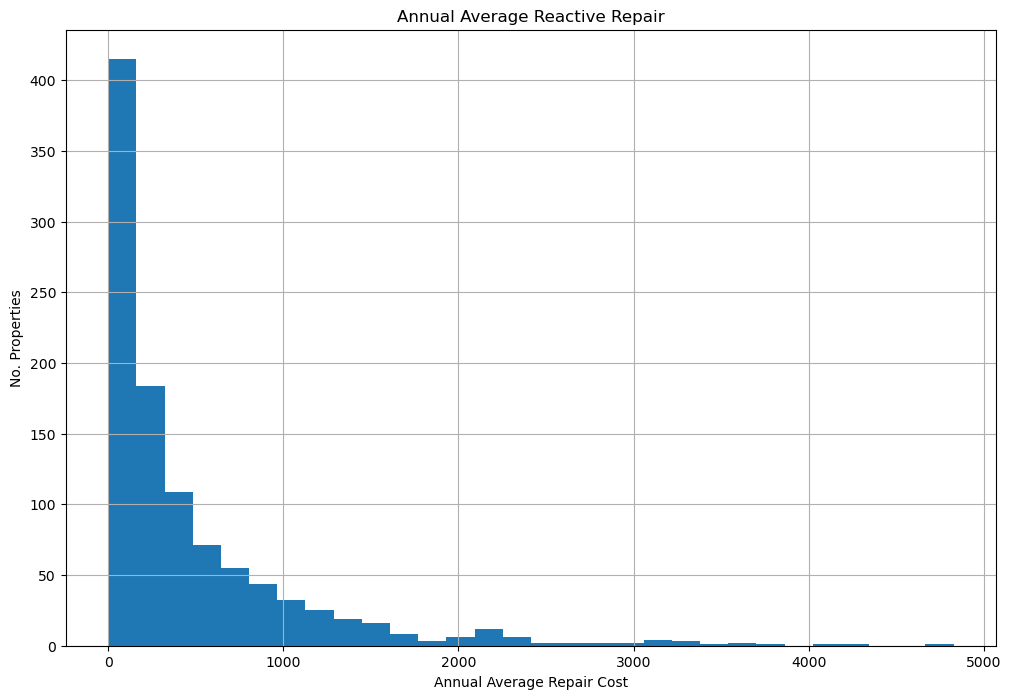

In [7]:
#Create histogram to view distribution

repairs.hist(figsize = (12,8), bins = 30)
plt.xlabel("Annual Average Repair Cost")
plt.ylabel("No. Properties")

plt.savefig("Repairs_Dist.png")

In [19]:
#Load data

Assets_Core = pd.read_csv("Assets.csv")

array([[<Axes: title={'center': 'Total Asset Score'}>,
        <Axes: title={'center': 'NPV Score'}>],
       [<Axes: title={'center': 'Neighbourhood Score'}>,
        <Axes: title={'center': 'Energy Efficiency'}>],
       [<Axes: title={'center': 'Demand Score'}>, <Axes: >]], dtype=object)

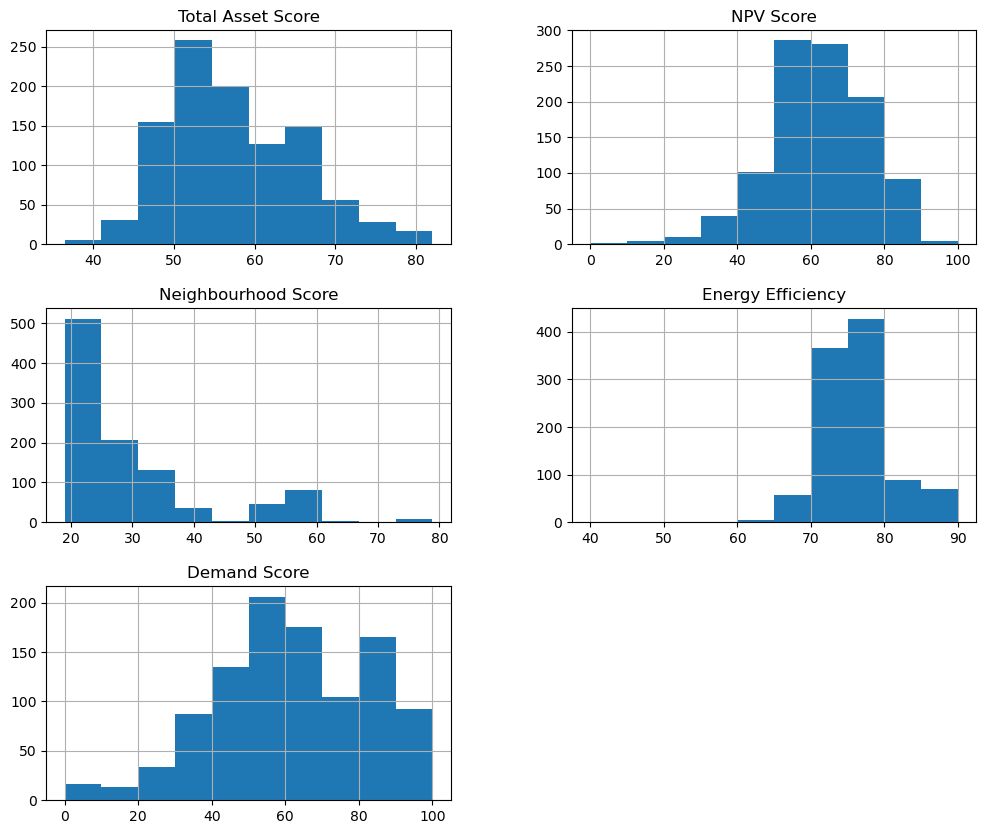

In [22]:
#Create histograms to view distributions

Assets_Core.hist(figsize = (12,10))

## Asset Scoring Corr analysis 

In [8]:
#Load data

assets = pd.read_csv("Asset_Scores.csv")

In [9]:
#Initial look

assets.head()

,PropertyID,Overall_Asset_Score,Normalized_NPV_0_to_100,Overall_Neighbourhood_Score_0_to_100,Energy_Score_0_to_100,Demand_Score_Normalised
0,COG01302,33.94,34.476319,21.607089,44.0,35.675793
1,GLA00103,35.87,35.415738,21.607089,66.0,20.445106
2,CEN0002E,36.02,0.000000,24.754042,76.0,43.316719
3,GLA00703,37.23,46.874596,21.607089,60.0,20.445106
4,SIM0008F,38.76,13.247141,21.607089,82.0,38.194582


In [10]:
#View shape

assets.shape

(1027, 6)

In [11]:
#Remove PropertyId column

assets_cleaned = assets.drop(columns= "PropertyID")

In [12]:
#View change

assets_cleaned.head()

,Overall_Asset_Score,Normalized_NPV_0_to_100,Overall_Neighbourhood_Score_0_to_100,Energy_Score_0_to_100,Demand_Score_Normalised
0,33.94,34.476319,21.607089,44.0,35.675793
1,35.87,35.415738,21.607089,66.0,20.445106
2,36.02,0.000000,24.754042,76.0,43.316719
3,37.23,46.874596,21.607089,60.0,20.445106
4,38.76,13.247141,21.607089,82.0,38.194582


In [13]:
#Convert to numeric

assets_cleaned = assets.apply(pd.to_numeric, errors="coerce")

In [14]:
#View datatypes

assets_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1027 entries, 0 to 1026
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PropertyID                            0 non-null      float64
 1   Overall_Asset_Score                   1027 non-null   float64
 2   Normalized_NPV_0_to_100               1027 non-null   float64
 3   Overall_Neighbourhood_Score_0_to_100  1027 non-null   float64
 4   Energy_Score_0_to_100                 1017 non-null   float64
 5   Demand_Score_Normalised               1027 non-null   float64
dtypes: float64(6)
memory usage: 48.3 KB


In [15]:
#Generate correlation matrix, Google Gemini used to generate code.

corr_matrix = assets_cleaned.corr(method='spearman')

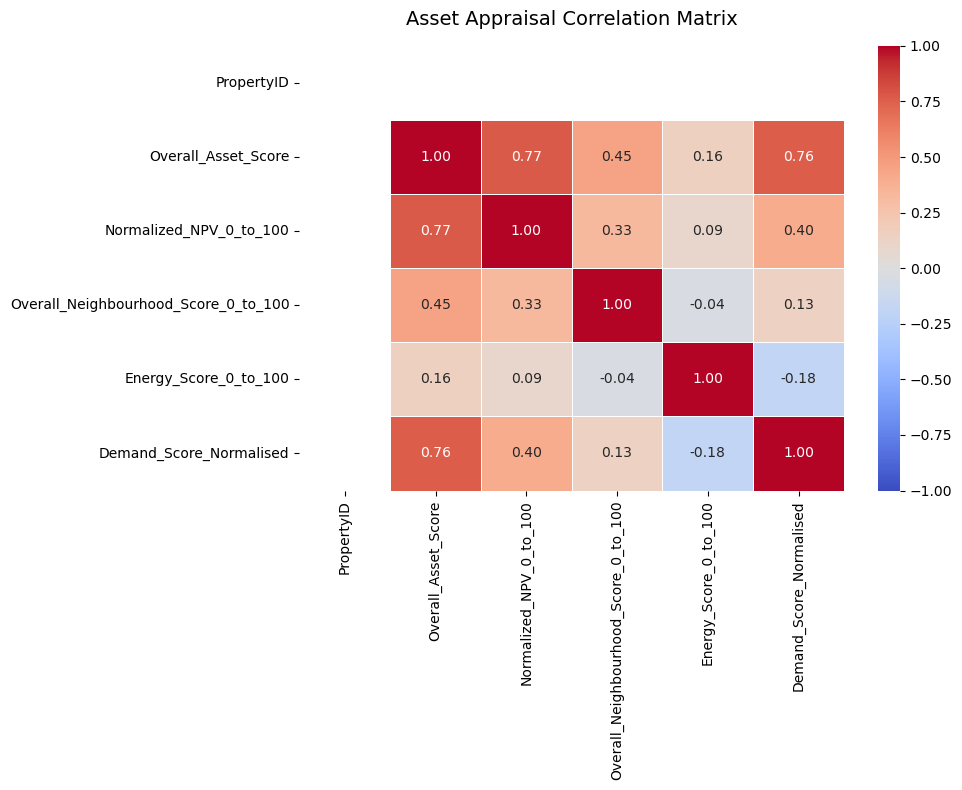

In [16]:
#Generate visual, Google Gemini used to generate code.

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    vmin=-1, vmax=1      
)

plt.title('Asset Appraisal Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Extract just the NPV correlations and sort them, Google Gemini used to generate.

#Checking correlation of Energy Efficiency Score with Overall Asset Score post normalisation

npv_drivers = corr_matrix[['Overall_Asset_Score']].sort_values(by='Overall_Asset_Score', ascending=False)

print("Strongest Predictors of Asset Score:")
print(npv_drivers)

Strongest Predictors of Asset Score:
                                      Overall_Asset_Score
Overall_Asset_Score                              1.000000
Normalized_NPV_0_to_100                          0.766843
Demand_Score_Normalised                          0.759314
Overall_Neighbourhood_Score_0_to_100             0.447014
Energy_Score_0_to_100                            0.155268
PropertyID                                            NaN


In [ ]:
#Dropping PropertyID

assets_core_cleaned = Assets_Core.drop(columns = "PropertyID")

In [ ]:
#Changing all columns to numeric

assets_core_cleaned = assets_core_cleaned.apply(pd.to_numeric, errors="coerce")

In [ ]:
#Generate correlation matrix, Google Gemini used to generate code.

corr_matrix_b = assets_core_cleaned.corr(method='spearman')

In [ ]:
#Checking correlation of Energy Efficiency Score with Total Asset Score pre normalisation

npv_drivers = corr_matrix_b[['Total Asset Score']].sort_values(by='Total Asset Score', ascending=False)

print("Strongest Predictors of Asset Score:")
print(npv_drivers)

Strongest Predictors of Asset Score:
                     Total Asset Score
Total Asset Score             1.000000
Demand Score                  0.794362
NPV Score                     0.766374
Neighbourhood Score           0.466549
Energy Efficiency             0.051405
